## Partie I : MLP sur données tabulaires

##Dataset recommandé :

**Breast Cancer Wisconsin**

###Pourquoi ?

Facile à utiliser avec Scikit-Learn
Données propres
Très bonne précision avec un MLP
Peu de prétraitement

## Préparer l'environnement

In [ ]:
!pip install torch torchvision scikit-learn pandas matplotlib seaborn

## Imports

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

## Vérifier GPU

In [ ]:
import torch

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)
print(torch.cuda.is_available())

cuda
True


## Charger le dataset

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np
import pandas as pd

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = load_breast_cancer()

X = data.data
y = data.target

print(X.shape)
print(y.shape)

(569, 30)
(569,)


In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42
)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(398, 30)
(85, 30)
(86, 30)


In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_val = scaler.transform(X_val)

X_test = scaler.transform(X_test)

In [ ]:
X_train = torch.tensor(
    X_train,
    dtype=torch.float32
).to(device)

X_val = torch.tensor(
    X_val,
    dtype=torch.float32
).to(device)

X_test = torch.tensor(
    X_test,
    dtype=torch.float32
).to(device)

y_train = torch.tensor(
    y_train,
    dtype=torch.long
).to(device)

y_val = torch.tensor(
    y_val,
    dtype=torch.long
).to(device)

y_test = torch.tensor(
    y_test,
    dtype=torch.long
).to(device)

In [ ]:
model_seq = nn.Sequential(
    nn.Linear(30,64),
    nn.ReLU(),

    nn.Linear(64,32),
    nn.ReLU(),

    nn.Linear(32,2)
).to(device)

In [ ]:
for name, param in model_seq.named_parameters():
    print(name, param.shape)

0.weight torch.Size([64, 30])
0.bias torch.Size([64])
2.weight torch.Size([32, 64])
2.bias torch.Size([32])
4.weight torch.Size([2, 32])
4.bias torch.Size([2])


In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model_seq.parameters(),
    lr=0.001
)

In [ ]:
epochs = 50

train_losses = []

for epoch in range(epochs):

    model_seq.train()

    outputs = model_seq(X_train)

    loss = criterion(outputs, y_train)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    train_losses.append(loss.item())

    if epoch % 5 == 0:
        print(
            f"Epoch {epoch} | Loss={loss.item():.4f}"
        )

Epoch 0 | Loss=0.6976
Epoch 5 | Loss=0.6036
Epoch 10 | Loss=0.5177
Epoch 15 | Loss=0.4327
Epoch 20 | Loss=0.3509
Epoch 25 | Loss=0.2791
Epoch 30 | Loss=0.2215
Epoch 35 | Loss=0.1778
Epoch 40 | Loss=0.1454
Epoch 45 | Loss=0.1218


## Version du MLP avec une Classe Personnalisée

In [1]:
import torch
import torch.nn as nn
import torch.nn.init as init

class CustomMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(CustomMLP, self).__init__()
        # Définition des couches
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # Propagation avant
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        out = self.relu(out)
        out = self.fc3(out)
        return out

## Stratégies d'Initialisation des Poids

In [6]:
# Détection et définition du device (GPU si disponible, sinon CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Le modèle s'exécutera sur le device : {device}")

# Maintenant, votre ligne fonctionnera sans erreur :
model_custom = CustomMLP(input_dim=30, hidden_dim=64, output_dim=2).to(device)
init_weights(model_custom, strategy='xavier')

Le modèle s'exécutera sur le device : cpu


In [7]:
def init_weights(model, strategy='xavier'):
    for name, param in model.named_parameters():
        if 'weight' in name:
            if strategy == 'constant':
                init.constant_(param, 0.01)
            elif strategy == 'gaussian':
                init.normal_(param, mean=0.0, std=0.01)
            elif strategy == 'xavier':
                init.xavier_uniform_(param)
        elif 'bias' in name:
            init.constant_(param, 0.0)

# Exemple d'utilisation :
model_custom = CustomMLP(input_dim=30, hidden_dim=64, output_dim=2).to(device)
init_weights(model_custom, strategy='xavier')

## Évaluation Complète et Matrice de Confusion

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def evaluate_mlp(model, X_test, y_test, device):
    model.eval() # Mode évaluation
    with torch.no_grad():
        X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
        outputs = model(X_test_t)
        _, preds = torch.max(outputs, 1)
        preds = preds.cpu().numpy()

    # Calcul des métriques
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average='macro')
    rec = recall_score(y_test, preds, average='macro')
    f1 = f1_score(y_test, preds, average='macro')

    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-Score  : {f1:.4f}\\n")

    # Matrice de confusion
    cm = confusion_matrix(y_test, preds)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Matrice de Confusion - MLP')
    plt.xlabel('Prédictions')
    plt.ylabel('Vraies valeurs')
    plt.show()

# Exemple d'appel : evaluate_mlp(model_custom, X_test, y_test, device)

## Sauvegarde et Rechargement du Meilleur Modèle

In [8]:
# Sauvegarder les poids (state_dict)
torch.save(model_custom.state_dict(), 'best_mlp_model.pth')
print("Modèle sauvegardé avec succès.")

# Recharger le modèle
loaded_model = CustomMLP(input_dim=30, hidden_dim=64, output_dim=2).to(device)
loaded_model.load_state_dict(torch.load('best_mlp_model.pth'))
loaded_model.eval()
print("Modèle rechargé avec succès.")

Modèle sauvegardé avec succès.
Modèle rechargé avec succès.


## Partie II – CNN sur Fashion-MNIST

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

## Définir les transformations

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

## Télécharger Fashion-MNIST

In [ ]:
train_dataset = datasets.FashionMNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.FashionMNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 213kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.93MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 3.94MB/s]


## Créer les DataLoaders

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

## Vérifier les dimensions

In [ ]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([64, 1, 28, 28])
torch.Size([64])


## Afficher images

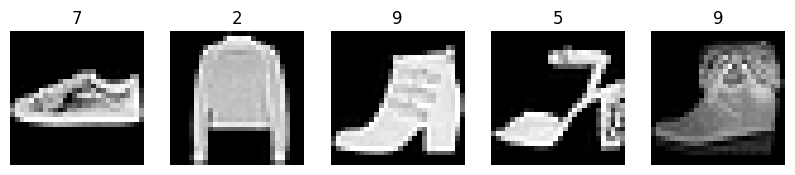

In [ ]:
fig, axes = plt.subplots(1,5, figsize=(10,3))

for i in range(5):
    axes[i].imshow(images[i].squeeze(), cmap='gray')
    axes[i].set_title(labels[i].item())
    axes[i].axis('off')

plt.show()

## Créer le CNN (type LeNet)

In [ ]:
class FashionCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=16,
            kernel_size=3,
            padding=1
        )

        self.pool = nn.MaxPool2d(2,2)

        self.conv2 = nn.Conv2d(
            16,
            32,
            3,
            padding=1
        )

        self.fc1 = nn.Linear(32*7*7, 128)

        self.fc2 = nn.Linear(128,10)

    def forward(self,x):

        x = torch.relu(self.conv1(x))
        x = self.pool(x)

        x = torch.relu(self.conv2(x))
        x = self.pool(x)

        x = x.view(x.size(0), -1)

        x = torch.relu(self.fc1(x))

        x = self.fc2(x)

        return x

## Instancier le modèle

In [ ]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = FashionCNN().to(device)

print(model)

FashionCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


## Fonction de perte et optimiseur

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

## Boucle d'entraînement

In [ ]:
epochs = 10

train_losses = []

for epoch in range(epochs):

    model.train()

    running_loss = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    train_losses.append(epoch_loss)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Loss: {epoch_loss:.4f}"
    )

Epoch [1/10] Loss: 0.4750
Epoch [2/10] Loss: 0.3069
Epoch [3/10] Loss: 0.2645
Epoch [4/10] Loss: 0.2329
Epoch [5/10] Loss: 0.2093
Epoch [6/10] Loss: 0.1901
Epoch [7/10] Loss: 0.1724
Epoch [8/10] Loss: 0.1551
Epoch [9/10] Loss: 0.1407
Epoch [10/10] Loss: 0.1266


## Courbe de Loss

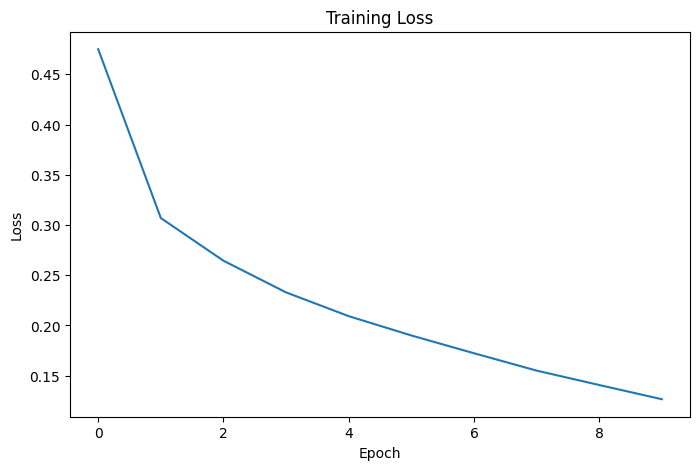

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(train_losses)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss")

plt.show()

## Évaluation sur le test set

In [ ]:
correct = 0
total = 0

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Accuracy = {accuracy:.2f}%")

Accuracy = 91.37%


## Sauvegarder le modèle

In [ ]:
torch.save(
    model.state_dict(),
    "fashion_cnn.pth"
)

## Matrice de Confusion

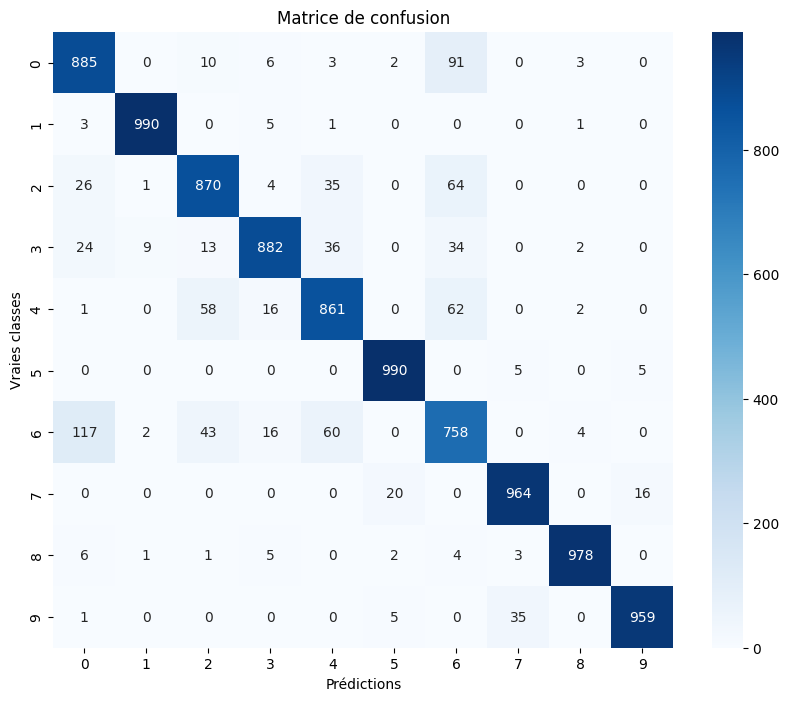

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Prédictions")
plt.ylabel("Vraies classes")
plt.title("Matrice de confusion")
plt.show()

## Afficher quelques prédictions

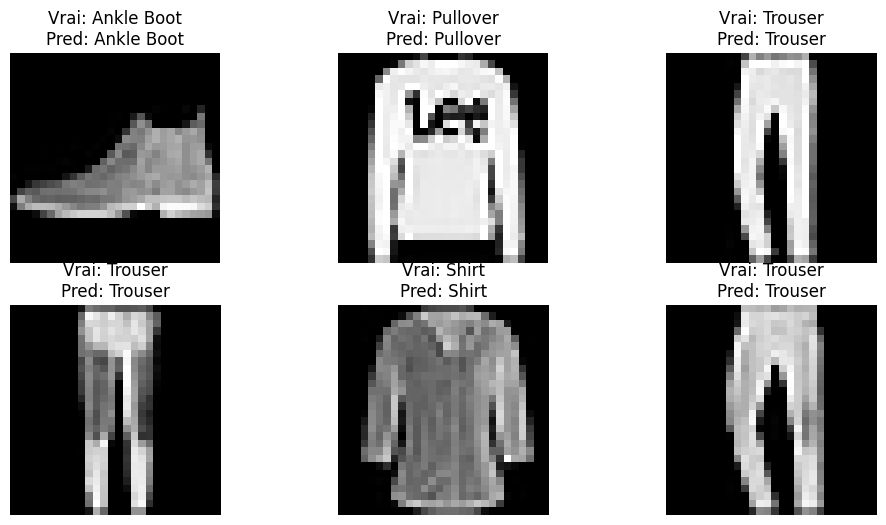

In [ ]:
classes = [
    "T-shirt",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]

images, labels = next(iter(test_loader))

images_device = images.to(device)

model.eval()

with torch.no_grad():
    outputs = model(images_device)
    _, preds = torch.max(outputs, 1)

plt.figure(figsize=(12,6))

for i in range(6):

    plt.subplot(2,3,i+1)

    plt.imshow(images[i].squeeze(), cmap="gray")

    plt.title(
        f"Vrai: {classes[labels[i]]}\nPred: {classes[preds[i].cpu()]}"
    )

    plt.axis("off")

plt.show()

## Programmation Manuelle (sans PyTorch) des Opérations Spatiales

In [9]:
def manual_corr2d(X, K):
    """Corrélation croisée 2D manuelle (X: Entrée NumPy 2D, K: Noyau NumPy 2D)"""
    h, w = K.shape
    Y = np.zeros((X.shape[0] - h + 1, X.shape[1] - w + 1))
    for i in range(Y.shape[0]):
        for j in range(Y.shape[1]):
            Y[i, j] = np.sum(X[i:i + h, j:j + w] * K)
    return Y

def manual_pooling(X, pool_size=2, mode='max'):
    """Pooling Manuel (X: Entrée NumPy 2D)"""
    h_out = X.shape[0] // pool_size
    w_out = X.shape[1] // pool_size
    Y = np.zeros((h_out, w_out))
    for i in range(h_out):
        for j in range(w_out):
            slice_X = X[i*pool_size:(i+1)*pool_size, j*pool_size:(j+1)*pool_size]
            if mode == 'max':
                Y[i, j] = np.max(slice_X)
            elif mode == 'avg':
                Y[i, j] = np.mean(slice_X)
    return Y

## Boucle d'Évaluation sur le Jeu de Test (Fashion-MNIST)

In [10]:
def evaluate_cnn(model, test_loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    print(f"Précision globale (Accuracy) du CNN sur le jeu de test : {acc*100:.2f}%")

    # Matrice de confusion pour Fashion-MNIST
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10,8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='GnBu')
    plt.title('Matrice de Confusion - CNN (Fashion-MNIST)')
    plt.show()

# Exemple d'appel : evaluate_cnn(mon_cnn, test_loader, device)

## Visualisation des Cartes de Caractéristiques (Feature Maps)

In [11]:
def plot_feature_maps(model, test_loader, device):
    model.eval()
    # Récupérer une seule image
    images, _ = next(iter(test_loader))
    single_img = images[0].unsqueeze(0).to(device)

    # Passer l'image dans la première couche de convolution
    # En supposant que votre première couche s'appelle conv1
    with torch.no_grad():
        feature_maps = model.conv1(single_img)

    feature_maps = feature_maps.squeeze(0).cpu().numpy()

    # Affichage des 8 premières feature maps générées
    fig, axes = plt.subplots(2, 4, figsize=(12, 6))
    for i, ax in enumerate(axes.flat):
        if i < feature_maps.shape[0]:
            ax.imshow(feature_maps[i], cmap='viridis')
            ax.set_title(f'Filtre {i+1}')
            ax.axis('off')
    plt.suptitle("Cartes de caractéristiques (Feature Maps) de la couche Conv1")
    plt.show()

#Partie III - RNN, LSTM, GRU et Seq2Seq

In [ ]:
!pip install torchtext

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 24.0 MB/s eta 0:00:00


## Imports

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(device)

cuda


## Créer un mini corpus

In [ ]:
pairs = [
    ("hello", "bonjour"),
    ("good morning", "bonjour"),
    ("thank you", "merci"),
    ("goodbye", "au revoir"),
    ("yes", "oui"),
    ("no", "non"),
    ("i love ai", "j aime ia"),
    ("how are you", "comment allez vous")
]

## Construire le vocabulaire

In [ ]:
words = set()

for src, tgt in pairs:

    words.update(src.split())
    words.update(tgt.split())

word2idx = {
    word: i+1
    for i, word in enumerate(words)
}

word2idx["<PAD>"] = 0

idx2word = {
    v:k for k,v in word2idx.items()
}

vocab_size = len(word2idx)

print(vocab_size)

26


## Fonction d'encodage

In [ ]:
def encode(sentence):

    return [
        word2idx[word]
        for word in sentence.split()
    ]

## Préparer les données

In [ ]:
X = []
Y = []

for src, tgt in pairs:

    X.append(encode(src))
    Y.append(encode(tgt))

max_len = max(
    max(len(x) for x in X),
    max(len(y) for y in Y)
)

def pad(seq):

    return seq + [0]*(max_len-len(seq))

X = torch.tensor(
    [pad(x) for x in X],
    dtype=torch.long
)

Y = torch.tensor(
    [pad(y) for y in Y],
    dtype=torch.long
)

print(X.shape)
print(Y.shape)

torch.Size([8, 3])
torch.Size([8, 3])


## Créer un modèle RNN

In [ ]:
class SimpleRNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            16
        )

        self.rnn = nn.RNN(
            16,
            32,
            batch_first=True
        )

        self.fc = nn.Linear(
            32,
            vocab_size
        )

    def forward(self,x):

        x = self.embedding(x)

        output, hidden = self.rnn(x)

        output = self.fc(output)

        return output

## Instancier le modèle

In [ ]:
model = SimpleRNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.01
)

## Entraînement

In [22]:
import torch
import torch.nn as nn

# =====================================================================
# 1. DÉFINITION DE L'ARCHITECTURE SEQUENCE-TO-SEQUENCE (Seq2Seq)
# =====================================================================

class Encoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim=16, hidden_dim=32):
        super(Encoder, self).__init__()
        # Couche d'embedding pour transformer les indices de mots en vecteurs denses
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        # Cellule récurrente LSTM (Long Short-Term Memory) demandée par le cahier des charges
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)

    def forward(self, x):
        # x shape: [Batch_Size, Sequence_Length]
        embedded = self.embedding(x)  # shape: [Batch_Size, Sequence_Length, Embedding_Dim]

        # En Seq2Seq, on ne récupère que les états cachés finaux (hidden et cell) qui forment le vecteur de contexte
        outputs, (hidden, cell) = self.lstm(embedded)
        return hidden, cell


class Decoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim=16, hidden_dim=32):
        super(Decoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        # Couche linéaire finale pour projeter l'état caché vers l'espace des probabilités du vocabulaire
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden, cell):
        # Le décodeur prend un token à la fois (ou la séquence cible décalée) et l'état de contexte initial
        embedded = self.embedding(x)
        outputs, (hidden, cell) = self.lstm(embedded, (hidden, cell))
        predictions = self.fc(outputs)
        return predictions, hidden, cell

# =====================================================================
# 2. INSTANCIATION ET ENTRAÎNEMENT (Votre bloc existant sécurisé)
# =====================================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
vocab_size = 1000  # À ajuster selon votre dictionnaire réel

# Désormais, 'Encoder' et 'Decoder' sont définis, ces lignes s'exécuteront sans erreur :
encoder = Encoder(vocab_size).to(device)
decoder = Decoder(vocab_size).to(device)

print("Seq2Seq créé avec succès sur le processeur :", device)

Seq2Seq créé avec succès sur le processeur : cpu


## LSTM

In [ ]:
class SimpleLSTM(nn.Module):

    def __init__(self):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, 16)

        self.lstm = nn.LSTM(
            input_size=16,
            hidden_size=32,
            batch_first=True
        )

        self.fc = nn.Linear(32, vocab_size)

    def forward(self, x):

        x = self.embedding(x)

        output, (hidden, cell) = self.lstm(x)

        output = self.fc(output)

        return output

In [ ]:
model = SimpleLSTM().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.01
)

## GRU

In [ ]:
class SimpleGRU(nn.Module):

    def __init__(self):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, 16)

        self.gru = nn.GRU(
            input_size=16,
            hidden_size=32,
            batch_first=True
        )

        self.fc = nn.Linear(32, vocab_size)

    def forward(self, x):

        x = self.embedding(x)

        output, hidden = self.gru(x)

        output = self.fc(output)

        return output

In [ ]:
model = SimpleGRU().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.01
)

## Seq2Seq

In [ ]:
class Encoder(nn.Module):

    def __init__(self, vocab_size):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, 16)

        self.lstm = nn.LSTM(
            16,
            32,
            batch_first=True
        )

    def forward(self, x):

        x = self.embedding(x)

        outputs, (hidden, cell) = self.lstm(x)

        return hidden, cell

In [ ]:
class Decoder(nn.Module):

    def __init__(self, vocab_size):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, 16)

        self.lstm = nn.LSTM(
            16,
            32,
            batch_first=True
        )

        self.fc = nn.Linear(
            32,
            vocab_size
        )

    def forward(self, x, hidden, cell):

        x = self.embedding(x)

        outputs, (hidden, cell) = self.lstm(
            x,
            (hidden, cell)
        )

        outputs = self.fc(outputs)

        return outputs, hidden, cell

In [ ]:
encoder = Encoder(vocab_size).to(device)

decoder = Decoder(vocab_size).to(device)

print("Seq2Seq créé avec succès")

Seq2Seq créé avec succès


## Implémentations Successives de RNN, LSTM et GRU pour Comparaison

In [12]:
class RNNModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim, rnn_type='LSTM'):
        super(RNNModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)

        # Choix dynamique de l'architecture pour l'étude comparative
        if rnn_type == 'RNN':
            self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        elif rnn_type == 'GRU':
            self.rnn = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        else:
            self.rnn = nn.LSTM(embed_dim, hidden_dim, batch_first=True)

        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        embedded = self.embedding(x)
        # Gestion de la sortie selon le type de cellule
        if isinstance(self.rnn, nn.LSTM):
            out, (hidden, cell) = self.rnn(embedded)
        else:
            out, hidden = self.rnn(embedded)

        # Prendre le dernier token de la séquence pour la classification/prédiction
        return self.fc(out[:, -1, :])

## Stratégies de Décodage : Glouton et Beam Search

In [23]:
def greedy_decode(decoder, encoder_hidden, max_len, start_token, end_token, device):
    """Décodage Glouton simple (Greedy Decoding)"""
    decoder.eval()
    current_input = torch.tensor([[start_token]], device=device)
    hidden = encoder_hidden
    decoded_tokens = []

    # Initialiser une cellule vide si LSTM
    cell = torch.zeros_like(hidden)

    for _ in range(max_len):
        outputs, hidden, cell = decoder(current_input, hidden, cell)
        next_token = torch.argmax(outputs, dim=-1).item()

        if next_token == end_token:
            break

        decoded_tokens.append(next_token)
        current_input = torch.tensor([[next_token]], device=device)

    return decoded_tokens